In [1]:
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *
import stackview
import copy

In [2]:
nparticles=10
nframes=40
nposframe=5
D_list = [
    (0.10, 0.30),  
    (0.50, 0.10),  
    (1.50, 0.15),  
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20)
]

In [3]:
# experiment: strong filamentous diffusion at 30 degrees
trajectories_aniso = simulate_brownian_motion(
    nparticles=nparticles,
    nframes=nframes,
    nposframe=nposframe,
    D_list=D_list,
    dt=1.0,
    anisotropy_ratio_range=(0.05, 0.2), # range of possible ratios D2/D1 -> very strong anisotropy
    theta_range=(np.deg2rad(30), np.deg2rad(30)),
    bg_size=(128, 128), # renommer frame size
    intensity_mean=700,
    intensity_std=300
)

image_props = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,   # trajectories already in pixels
    "invert_y": True,
}

video_aniso= trajectories_to_global_video(
    trajectories_aniso, # still at subframe resolution
    nframes=nframes,
    nPosPerFrame=nposframe,
    image_props=image_props,
)

#animate_video(video_aniso, interval=100)

In [4]:
# gif_title=f'aniso_{nparticles}p_{nframes}f.gif'
# save_video_as_gif(video_aniso, gif_title, fps=10)

In [5]:
# create trajectories_GT, the upsampled version of trajectories for comparison with detected and localized trajectories
# current trajectories are of length nframes * nposframe, but we want to compare with trajectories at frame resolution (nframes)
def create_GT_trajectories(trajectories, nposframe):
    trajectories_GT = copy.deepcopy(trajectories)
    for traj in trajectories_GT:
        traj.positions = traj.positions[::nposframe]
        traj.positions = [(128-pos[1], pos[0]) for pos in traj.positions]
        traj.end_frame = traj.start_frame + len(traj.positions) - 1
    return trajectories_GT

In [6]:
trajectories_GT = create_GT_trajectories(trajectories_aniso, nposframe)

In [7]:
frames = video_aniso.astype(np.float32)
print(frames.shape)

(40, 128, 128)


# 2. Diffusion coefficient estimation

### 2.0 $ D_{GT} $

In [8]:
# print D_GT as a simple list
D_GT = [(traj.D1_GT, traj.D2_GT) for traj in trajectories_aniso]
print("D_GT:", D_GT)


D_GT: [(0.1, 0.015396919737869968), (5.0, 0.5432685738186527), (3.5, 0.29263085696722596), (0.1, 0.018534777239062213), (0.5, 0.07652655463524377), (5.0, 0.5744221576966553), (5.0, 0.29578094598537175), (0.1, 0.015635217366613295), (1.5, 0.1722412703729361), (5.0, 0.7672346481736253)]


### 2.1 $ D_{trajectory} $

In [9]:
calculate_msd_trajectories(trajectories_GT)
estimate_diffusion_tensors(trajectories_GT, target="trajectory")

[{'id': 0,
  'D1': 0.13594453303307363,
  'D2': 0.053535809582454026,
  'theta': 1.8890453417787867,
  'D_iso': 0.09474017130776383,
  'anisotropy': 0.3938062707488901,
  'D_tensor': array([[ 0.06160436, -0.02449117],
         [-0.02449117,  0.12787599]])},
 {'id': 1,
  'D1': 6.914878716940125,
  'D2': 4.190395711894789,
  'theta': 1.3087814091561654,
  'D_iso': 5.552637214417457,
  'anisotropy': 0.6059969933571104,
  'D_tensor': array([[4.37319518, 0.68162922],
         [0.68162922, 6.73207925]])},
 {'id': 2,
  'D1': 4.642358400507682,
  'D2': 2.6750814213710683,
  'theta': 0.28458111099760686,
  'D_iso': 3.658719910939375,
  'anisotropy': 0.5762332828672868,
  'D_tensor': array([[4.48729052, 0.53010888],
         [0.53010888, 2.8301493 ]])},
 {'id': 3,
  'D1': 0.09787168764517029,
  'D2': 0.08627974844839972,
  'theta': 1.9523123199493244,
  'D_iso': 0.09207571804678501,
  'anisotropy': 0.8815598312885269,
  'D_tensor': array([[ 0.08788672, -0.00400569],
         [-0.00400569,  0.096

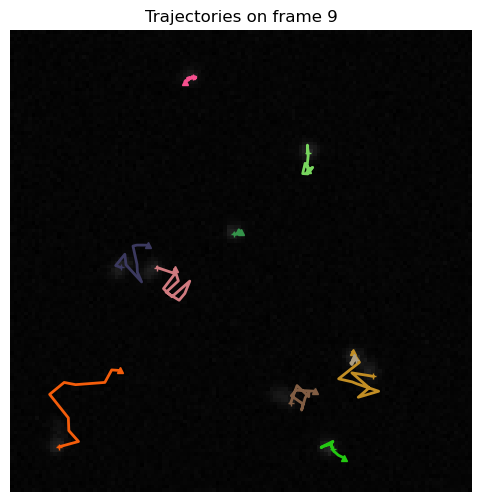

In [10]:
show_trajectories(frames, trajectories_GT, frame_id=9)

### 2.2 $ D_{detection} $

In [11]:
detected_peaks = detect_peaks(frames)
# TODO: get intensity (only in loclization?)

In [12]:
print(detected_peaks[0])

[[ 90  94]
 [ 54  63]
 [ 13  49]
 [118  92]
 [ 37  81]
 [118  90]
 [ 95  29]
 [ 65  44]
 [ 99  81]
 [ 67  44]
 [ 59  35]
 [ 58  37]]


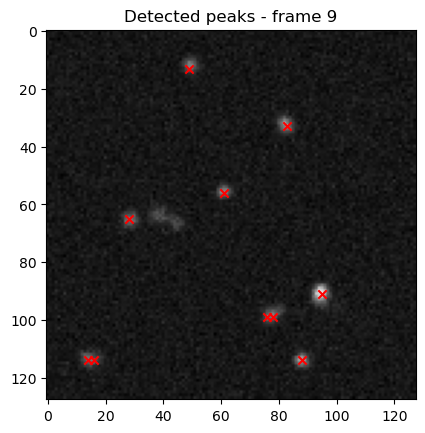

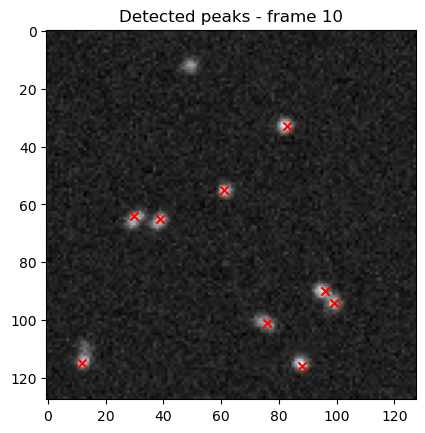

In [13]:
i = 8
visualize_peaks(detected_peaks[i], frames[i], i)
visualize_peaks(detected_peaks[i+1], frames[i+1], i+1)

### 2.3 $ D_{localization} $

In [14]:
import torch
import torch.nn as nn


class CostTerm(nn.Module):
    def __init__(self, weight=1.0, norm=1.0, enabled=True):
        super().__init__()
        self.weight = weight
        self.norm = norm
        self.enabled = enabled

    def forward(self, trajectory, detection):
        raise NotImplementedError


class DistanceTerm(CostTerm):
    def forward(self, trajectory, detection):
        if not self.enabled:
            return torch.tensor(0.0)

        pos, _, _ = detection

        last_pos = torch.as_tensor(
            trajectory.last_position(),
            dtype=torch.float32,
        )

        pos = torch.as_tensor(pos, dtype=torch.float32)

        dist = torch.linalg.norm(last_pos - pos)
        return self.weight * (dist / self.norm)


class IntensityTerm(CostTerm):
    def forward(self, trajectory, detection):
        if not self.enabled:
            return torch.tensor(0.0)

        _, det_intensity, _ = detection
        last_intensity = trajectory.last_intensity()

        if last_intensity is None or det_intensity is None:
            return torch.tensor(0.0)

        last_intensity = torch.as_tensor(last_intensity, dtype=torch.float32)
        det_intensity = torch.as_tensor(det_intensity, dtype=torch.float32)

        diff = torch.abs(last_intensity - det_intensity)
        return self.weight * (diff / self.norm)


class SigmaTerm(CostTerm):
    def forward(self, trajectory, detection):
        if not self.enabled:
            return torch.tensor(0.0)

        _, _, det_sigma = detection # ((x,y),int,sigma)
        last_sigma = trajectory.last_sigma()

        if last_sigma is None or det_sigma is None:
            return torch.tensor(0.0)

        last_sigma = torch.as_tensor(last_sigma, dtype=torch.float32)
        det_sigma = torch.as_tensor(det_sigma, dtype=torch.float32)

        diff = torch.abs(last_sigma - det_sigma)
        return self.weight * (diff / self.norm)


class PeakToPeak(nn.Module):
    def __init__(self, terms=None, return_breakdown=False):
        super().__init__()

        if terms is None:
            terms = {}

        self.terms = nn.ModuleDict(terms)
        self.return_breakdown = return_breakdown

    @classmethod
    def default(cls):
        return cls(
            terms={
                "distance": DistanceTerm(weight=0.5, norm=0.25 * 128),
                "intensity": IntensityTerm(weight=0.4, norm=650),
                "sigma": SigmaTerm(weight=0.1, norm=2.0),
            }
        )

    def forward(self, trajectory, detection):
        costs = {
            name: term(trajectory, detection)
            for name, term in self.terms.items()
        }

        total = sum(costs.values())

        if self.return_breakdown:
            return total, costs

        return total


In [15]:
custom_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=1.0, norm=5),
        "intensity": IntensityTerm(weight=0.25, norm=650),
    }
)

In [16]:
# global tracking function that does detection of peaks, localization (by gaussian fitting) of centers, linking of localized peaks into trajectories and assignment to GT trajectories, with all the intermediate steps and results visualized
def track(
    frames,
    trajectories_GT,
    max_distance=10,
    min_length=5, # à affiner, trouver un bon min, taille min Emilien
    algo_peak2peak='hungarian',
    algo_traj2traj='hungarian',
    cost_function=None,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False
):
    detected_peaks = detect_peaks(frames)
    
    localized_peaks = localize_peaks_with_gaussian_fitting(frames, 
                                                           detected_peaks, 
                                                           r_squared_threshold=0.5, 
                                                           verbose=verbose_loc, 
                                                           visualization=visualization_loc, 
                                                           visualization_peak_idx=1)

    trajectories_localization, cost_peak2peak = track_peaks_to_trajectories(
                                                        peaks=localized_peaks,
                                                        max_distance=max_distance,
                                                        min_length=min_length,
                                                        algorithm=algo_peak2peak,
                                                        cost_function=cost_function,
                                                )

    trajectories_localization, cost_traj2traj, assignment_localization = assign_trajectories(trajectories_localization,
                                                                                             trajectories_GT, 
                                                                                             algorithm=algo_traj2traj, 
                                                                                             verbose=verbose_assignment)

    return trajectories_localization, cost_peak2peak, assignment_localization, cost_traj2traj

[Frame [[ 37.852226 145.51192   72.44637  ... 104.25086  117.43798   79.05206 ]
 [139.75027  146.8723   107.43464  ...  52.25645   64.94099   92.55002 ]
 [ 83.89293  110.84594   68.30887  ... 124.43816   86.50996   77.80267 ]
 ...
 [134.39197  131.01244  117.55685  ... 133.64528  131.64561  119.33032 ]
 [107.00231   73.422134 131.41391  ...  80.43954  111.51086  117.447   ]
 [118.59382   66.37143   94.88154  ... 125.60175  115.553825  98.703865]]] Fitted center for peak at (90, 94): (89.30, 94.50), amplitude 1055.31, sigma 1.68
[Frame [[ 37.852226 145.51192   72.44637  ... 104.25086  117.43798   79.05206 ]
 [139.75027  146.8723   107.43464  ...  52.25645   64.94099   92.55002 ]
 [ 83.89293  110.84594   68.30887  ... 124.43816   86.50996   77.80267 ]
 ...
 [134.39197  131.01244  117.55685  ... 133.64528  131.64561  119.33032 ]
 [107.00231   73.422134 131.41391  ...  80.43954  111.51086  117.447   ]
 [118.59382   66.37143   94.88154  ... 125.60175  115.553825  98.703865]]] Fitted center 

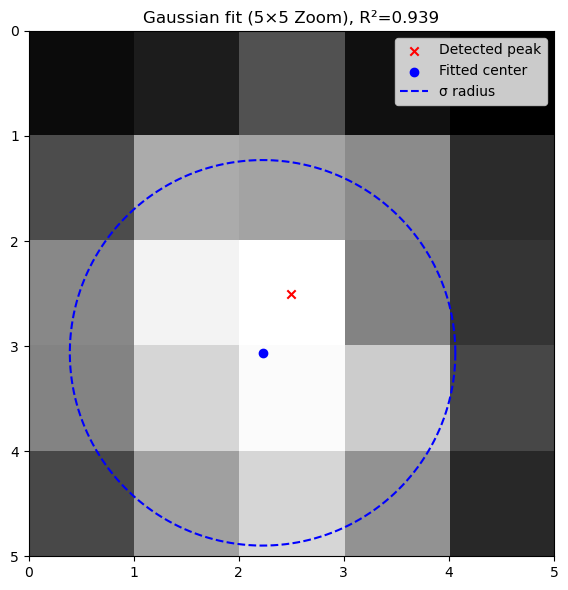

[Frame [[ 37.852226 145.51192   72.44637  ... 104.25086  117.43798   79.05206 ]
 [139.75027  146.8723   107.43464  ...  52.25645   64.94099   92.55002 ]
 [ 83.89293  110.84594   68.30887  ... 124.43816   86.50996   77.80267 ]
 ...
 [134.39197  131.01244  117.55685  ... 133.64528  131.64561  119.33032 ]
 [107.00231   73.422134 131.41391  ...  80.43954  111.51086  117.447   ]
 [118.59382   66.37143   94.88154  ... 125.60175  115.553825  98.703865]]] Fitted center for peak at (13, 49): (13.17, 48.10), amplitude 805.39, sigma 1.38
[Frame [[ 37.852226 145.51192   72.44637  ... 104.25086  117.43798   79.05206 ]
 [139.75027  146.8723   107.43464  ...  52.25645   64.94099   92.55002 ]
 [ 83.89293  110.84594   68.30887  ... 124.43816   86.50996   77.80267 ]
 ...
 [134.39197  131.01244  117.55685  ... 133.64528  131.64561  119.33032 ]
 [107.00231   73.422134 131.41391  ...  80.43954  111.51086  117.447   ]
 [118.59382   66.37143   94.88154  ... 125.60175  115.553825  98.703865]]] Fitted center f

In [17]:
trajectories_localization, cost_peaks_to_trajectories, assignment_localization, cost_GT_assignment = track(
    frames,
    trajectories_GT,
    max_distance=10,
    min_length=5,
    algo_peak2peak='hungarian',
    algo_traj2traj='hungarian',
    cost_function=custom_cost,
    verbose_loc=True,
    visualization_loc=True,
    verbose_assignment=True
)

In [18]:
print(f"=> Localized {len(trajectories_localization)} trajectories.")
# print number of trajectories reassined to GT trajectories
n_reassigned = sum(1 for traj in trajectories_localization if traj.id != -1)
print(f"=> Reassigned {n_reassigned} trajectories to GT trajectories.")

=> Localized 26 trajectories.
=> Reassigned 10 trajectories to GT trajectories.


## 3. MSD Calculation

In [19]:
calculate_msd_trajectories(trajectories_localization)
MAE_D1_loc, MAE_D2_loc = compute_tensor_MAE(
    trajectories_localization,
    trajectories_GT,
    target="localization",
)

localization D1:
['0.075', '2.969', '1.365', '0.081', '0.490', '2.496', '5.240', '0.064', '0.961', '8.548']
localization D2:
['0.024', '1.636', '0.448', '0.057', '0.185', '1.402', '1.892', '0.034', '0.537', '1.319']
MAE D1:
['0.025', '2.031', '2.135', '0.019', '0.010', '2.504', '0.240', '0.036', '0.539', '3.548']
MAE D2:
['0.009', '1.093', '0.155', '0.039', '0.109', '0.828', '1.597', '0.019', '0.365', '0.552']


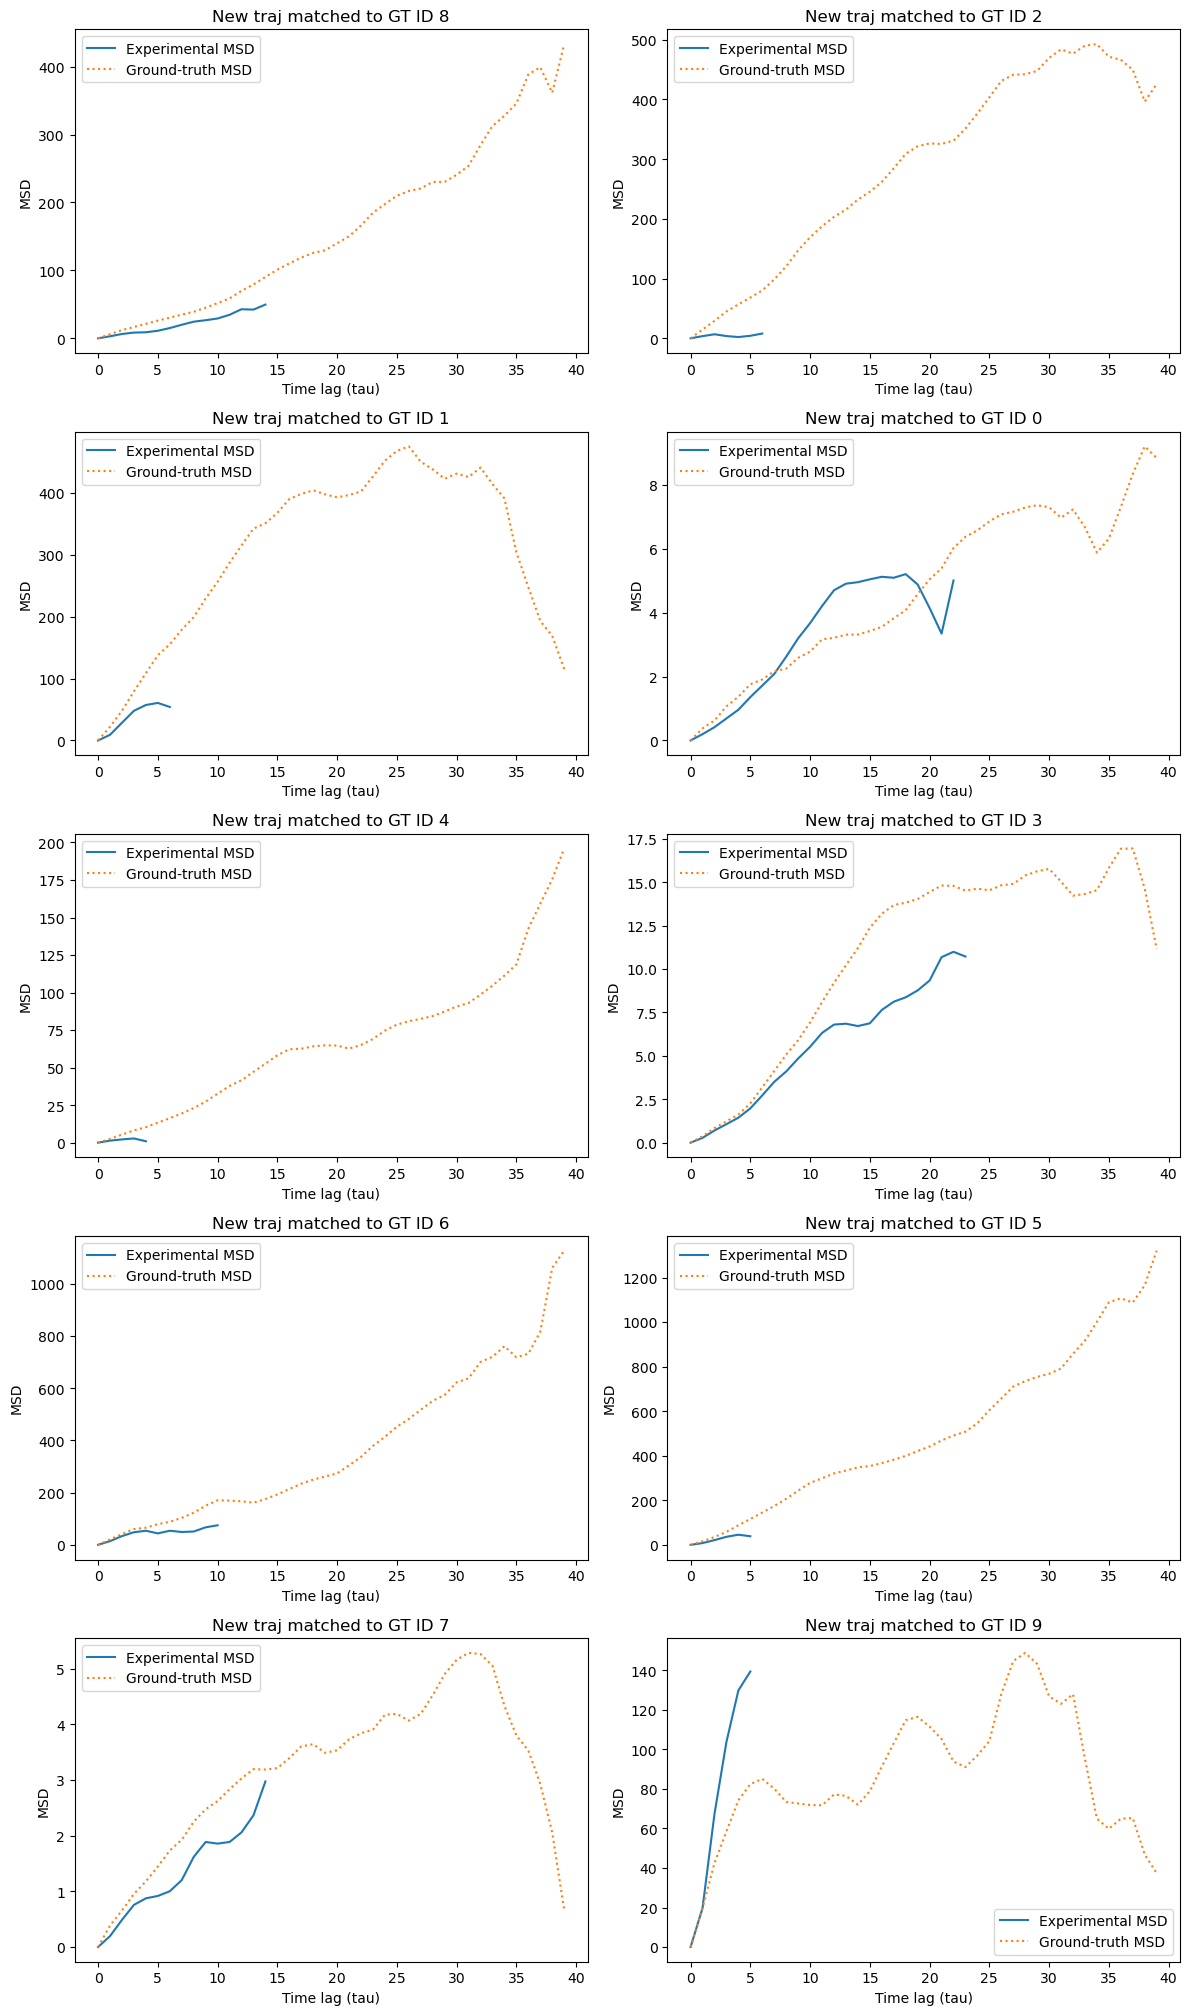

In [20]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)

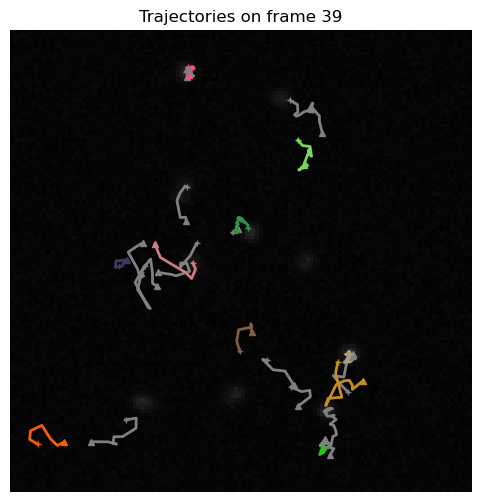

In [21]:
show_trajectories(frames, trajectories_localization, frame_id=nframes-1)

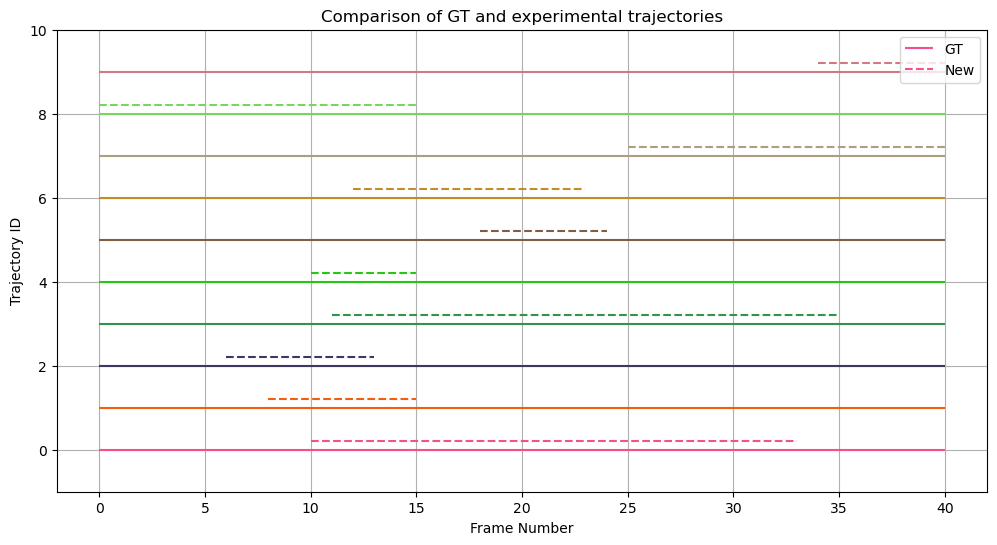

In [22]:
linear_trajectories_visualizer(trajectories_localization, trajectories_GT)

### New functionality #1: hide static particles

In [23]:
def hide_immobile_trajectories(frames, trajectories, threshold=0.2):
    frames_hidden = frames.copy()
    nframes = frames_hidden.shape[0]

    for traj in trajectories:

        # immobile if both principal diffusion coefficients are tiny
        D1 = traj.D1_localization
        D2 = traj.D2_localization

        if (not np.isnan(D1) and not np.isnan(D2) 
            and D1 < threshold and D2 < threshold):

            print(f"Hiding trajectory {traj.id} with D1={D1:.3f}, D2={D2:.3f}")

            for f in range(nframes):

                pos = traj.get_position_at_frame(f)
                if pos is None:
                    continue

                y, x = int(pos[0]), int(pos[1])

                sigma = traj.get_sigma_at_frame(f)
                if sigma is None:
                    continue

                patch_size = max(4 * math.ceil(sigma), 3)
                half = patch_size // 2

                # boundaries
                y0 = max(0, y - half)
                y1 = min(frames_hidden.shape[1], y + half)
                x0 = max(0, x - half)
                x1 = min(frames_hidden.shape[2], x + half)

                # background patch
                patch = np.random.normal(
                    loc=image_props["background_intensity"][0],
                    scale=image_props["background_intensity"][1],
                    size=(y1 - y0, x1 - x0)
                )
                patch = np.clip(patch, 0, 1000)

                frames_hidden[f, y0:y1, x0:x1] = patch

    return frames_hidden


In [24]:
frames_aniso_hidden = hide_immobile_trajectories(frames, trajectories_localization)

Hiding trajectory -1 with D1=0.095, D2=0.029
Hiding trajectory -1 with D1=0.133, D2=0.005
Hiding trajectory 0 with D1=0.075, D2=0.024
Hiding trajectory 3 with D1=0.081, D2=0.057
Hiding trajectory 7 with D1=0.064, D2=0.034
Hiding trajectory -1 with D1=0.103, D2=0.050


In [25]:
animate_video(frames, interval=100)

In [26]:
animate_video(frames_aniso_hidden, interval=100)

### New functionality #2: patch extraction to feed to MiViT

In [27]:
def extract_patches_per_id(frames, traj, patch_size=11):
    half = patch_size // 2
    patches = []

    # iterate over (frame index, position)
    for frame_idx, pos in zip(traj.frames(), traj.positions):
        y, x = int(pos[0]), int(pos[1])

        # extract patch
        patch = frames[
            frame_idx,
            y-half:y+half+1,
            x-half:x+half+1
        ]

        # skip if patch is incomplete (near borders)
        if patch.shape != (patch_size, patch_size):
            continue

        patches.append(patch)

    return np.array(patches)

In [28]:
# for all trajectorires ids
def extract_patches(frames, trajectories, patch_size=11):
    patches_list = []

    for traj in trajectories:
        patches_traj = extract_patches_per_id(
            frames, traj, patch_size=patch_size   # pass traj object directly
        )
        patches_list.append((traj.id, patches_traj))

    # Determine max length
    max_len = max(len(p) for _, p in patches_list)

    # Prepare padded array
    padded = np.zeros(
        (len(patches_list), max_len, patch_size, patch_size),
        dtype=patches_list[0][1][0].dtype
    )

    ids = []

    for i, (traj_id, traj_patches) in enumerate(patches_list):
        ids.append(traj_id)
        L = len(traj_patches)
        padded[i, :L] = traj_patches

    return padded, ids

patches, patch_ids = extract_patches(frames, trajectories_localization)

In [29]:
print(len(trajectories_localization[7].positions))

def visualize_particle_patches(patches, traj_id=None):
    # Remove padded frames
    mask = patches.sum(axis=(1,2)) > 0
    real_patches = patches[mask]
    print(f"Visualizing {real_patches.shape[0]} patches for trajectory ID {traj_id}")

    nframes = real_patches.shape[0]
    fig, axes = plt.subplots(1, nframes, figsize=(2*nframes, 3))
    axes = np.atleast_1d(axes)

    for j in range(nframes):
        axes[j].imshow(real_patches[j], cmap='gray')
        title = f"Frame {j}"
        axes[j].set_title(title)
        axes[j].axis('off')

    plt.suptitle(f"Trajectory ID: {traj_id}")
    plt.tight_layout()
    plt.show()
    

7


Visualizing 5 patches for trajectory ID -1


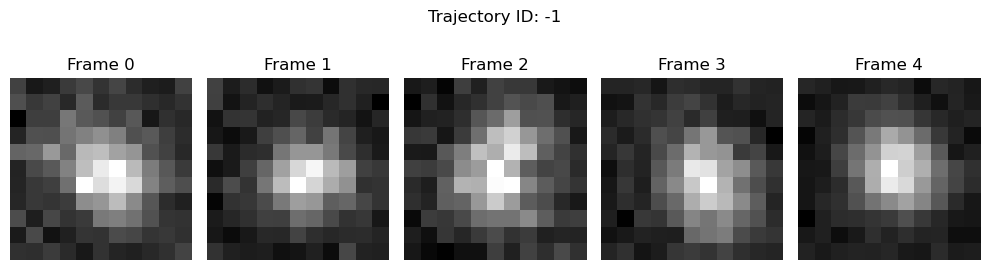

In [30]:
patches, patch_ids = extract_patches(frames, trajectories_localization)

i = 3  # list index
traj_id = patch_ids[i]

visualize_particle_patches(patches[i], traj_id=traj_id)